In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

In [65]:
df = pd.read_csv('insurance.csv')

In [66]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


EDA

In [67]:
df.shape

(1338, 7)

In [68]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [70]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [71]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [72]:
numeric_columns = df.select_dtypes(include=np.number).columns
numeric_columns

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

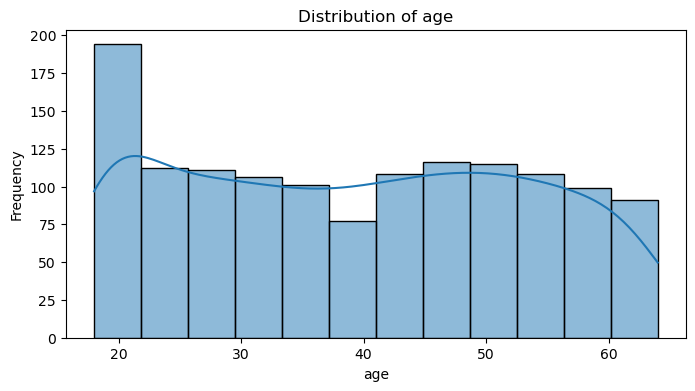

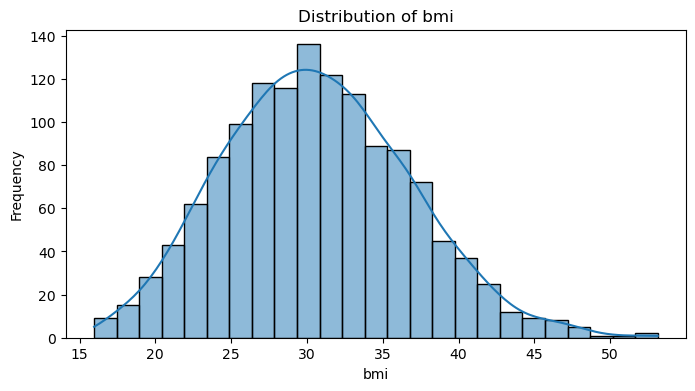

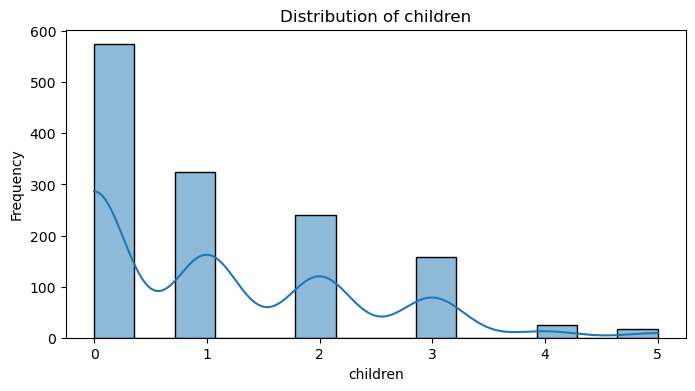

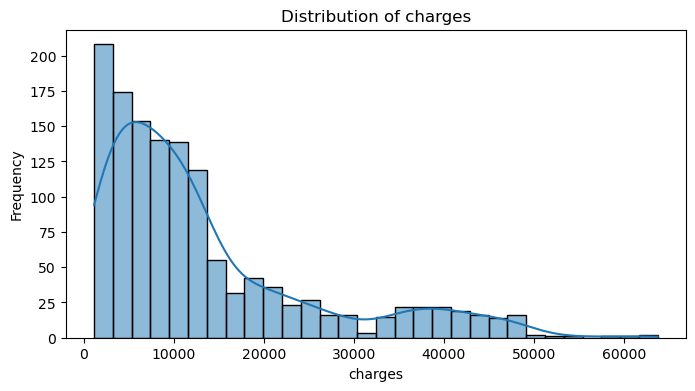

In [73]:
for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

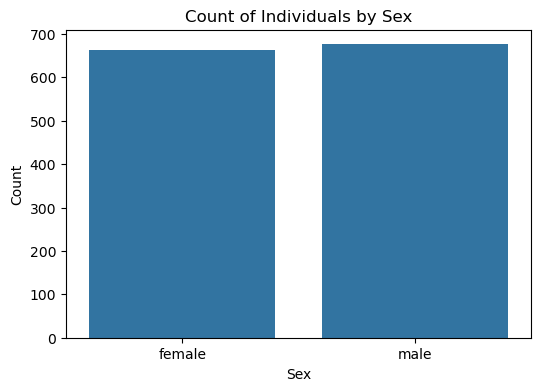

In [74]:
# Visualize the count of individuals by sex
plt.figure(figsize=(6, 4))
sns.countplot(x='sex', data=df)
plt.title('Count of Individuals by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

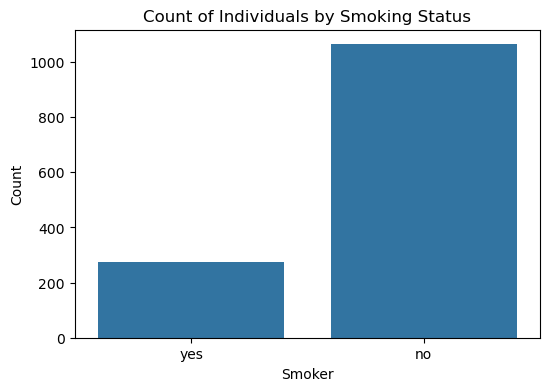

In [75]:
# Visualize the count of individuals by smoking status
plt.figure(figsize=(6, 4))
sns.countplot(x='smoker', data=df)
plt.title('Count of Individuals by Smoking Status')
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.show()

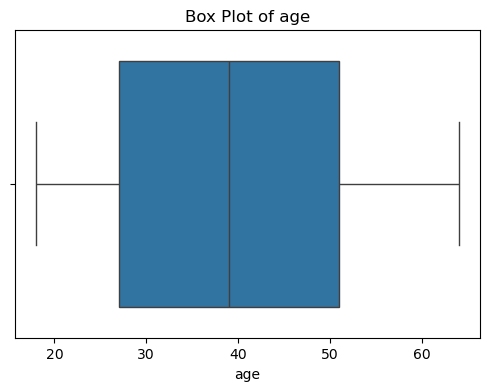

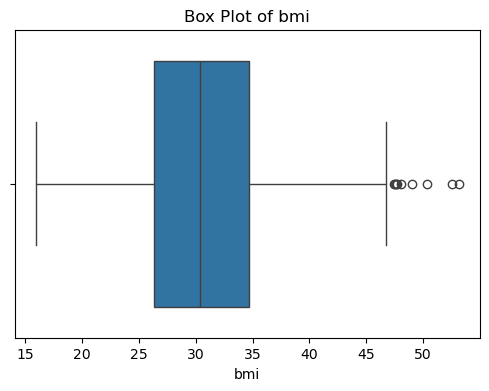

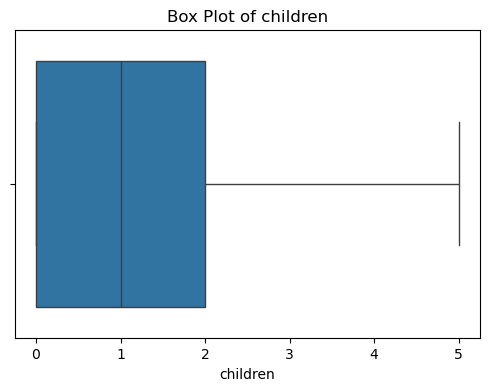

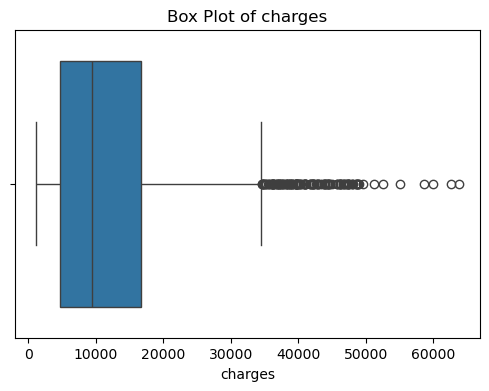

In [76]:
for column in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column])
    plt.title(f'Box Plot of {column}')
    plt.xlabel(column)
    plt.show()

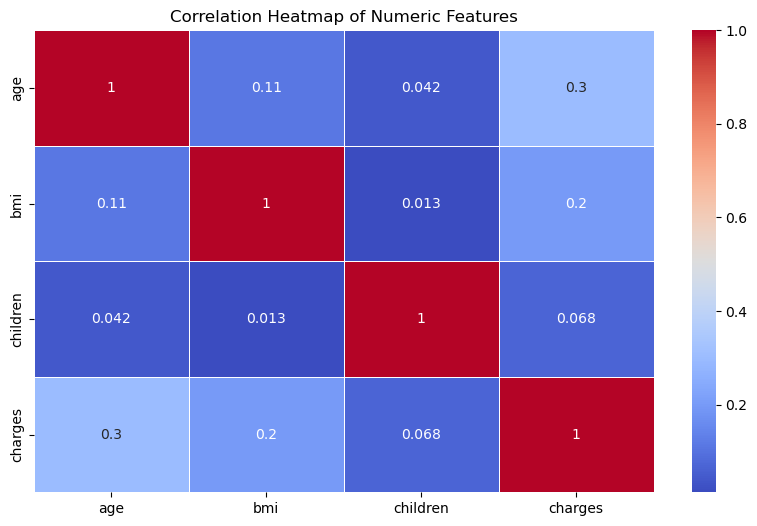

In [77]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_columns].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

Data Cleaning and Preprocessing

In [78]:
df_cleaned = df.copy()

In [79]:
# Drop rows with missing values (if any)
df_cleaned = df.dropna()

In [80]:
# Drop duplicate rows (if any)
df_cleaned.drop_duplicates(inplace=True)


In [81]:
#missing values and duplicates check after cleaning
df_cleaned.isnull().sum()   

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [82]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [83]:
# Encode the 'sex' column
df_cleaned['sex'] = df_cleaned['sex'].map({'male': 0, 'female': 1})
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,no,northwest,10600.54830
1334,18,1,31.920,0,no,northeast,2205.98080
1335,18,1,36.850,0,no,southeast,1629.83350
1336,21,1,25.800,0,no,southwest,2007.94500


In [84]:
# Encode the 'smoker' column
df_cleaned['smoker'] = df_cleaned['smoker'].map({'no': 0, 'yes': 1})
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [85]:
#rename sex and smoker columns as isfemale and issmoker for better understanding
df_cleaned.rename(columns={'sex': 'isfemale', 'smoker': 'issmoker'}, inplace=True)
df_cleaned

,age,isfemale,bmi,children,issmoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [86]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [87]:
#encode the 'region' column using one-hot encoding
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], drop_first=True)
df_cleaned

,age,isfemale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False
1334,18,1,31.920,0,0,2205.98080,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,True


In [88]:
df_cleaned=df_cleaned.astype('float64')
df_cleaned


,age,isfemale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest
0,19.0,1.0,27.900,0.0,1.0,16884.92400,0.0,0.0,1.0
1,18.0,0.0,33.770,1.0,0.0,1725.55230,0.0,1.0,0.0
2,28.0,0.0,33.000,3.0,0.0,4449.46200,0.0,1.0,0.0
3,33.0,0.0,22.705,0.0,0.0,21984.47061,1.0,0.0,0.0
4,32.0,0.0,28.880,0.0,0.0,3866.85520,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1333,50.0,0.0,30.970,3.0,0.0,10600.54830,1.0,0.0,0.0
1334,18.0,1.0,31.920,0.0,0.0,2205.98080,0.0,0.0,0.0
1335,18.0,1.0,36.850,0.0,0.0,1629.83350,0.0,1.0,0.0
1336,21.0,1.0,25.800,0.0,0.0,2007.94500,0.0,0.0,1.0


Feature Engineering and Extraction

In [89]:
# Create a new column 'bmi_category' based on the 'bmi' values
df_cleaned['bmi_category'] = pd.cut(df_cleaned['bmi'], bins=[0, 18.5, 24.9, 29.9, np.inf], labels=['Underweight', 'Normal weight', 'Overweight', 'Obese'])
df_cleaned

,age,isfemale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19.0,1.0,27.900,0.0,1.0,16884.92400,0.0,0.0,1.0,Overweight
1,18.0,0.0,33.770,1.0,0.0,1725.55230,0.0,1.0,0.0,Obese
2,28.0,0.0,33.000,3.0,0.0,4449.46200,0.0,1.0,0.0,Obese
3,33.0,0.0,22.705,0.0,0.0,21984.47061,1.0,0.0,0.0,Normal weight
4,32.0,0.0,28.880,0.0,0.0,3866.85520,1.0,0.0,0.0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50.0,0.0,30.970,3.0,0.0,10600.54830,1.0,0.0,0.0,Obese
1334,18.0,1.0,31.920,0.0,0.0,2205.98080,0.0,0.0,0.0,Obese
1335,18.0,1.0,36.850,0.0,0.0,1629.83350,0.0,1.0,0.0,Obese
1336,21.0,1.0,25.800,0.0,0.0,2007.94500,0.0,0.0,1.0,Overweight


In [90]:
#ENCODE THE 'bmi_category' COLUMN USING ONE-HOT ENCODING
df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_category'], drop_first=True)
df_cleaned = df_cleaned.astype('float64')
df_cleaned

,age,isfemale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obese
0,19.0,1.0,27.900,0.0,1.0,16884.92400,0.0,0.0,1.0,0.0,1.0,0.0
1,18.0,0.0,33.770,1.0,0.0,1725.55230,0.0,1.0,0.0,0.0,0.0,1.0
2,28.0,0.0,33.000,3.0,0.0,4449.46200,0.0,1.0,0.0,0.0,0.0,1.0
3,33.0,0.0,22.705,0.0,0.0,21984.47061,1.0,0.0,0.0,1.0,0.0,0.0
4,32.0,0.0,28.880,0.0,0.0,3866.85520,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50.0,0.0,30.970,3.0,0.0,10600.54830,1.0,0.0,0.0,0.0,0.0,1.0
1334,18.0,1.0,31.920,0.0,0.0,2205.98080,0.0,0.0,0.0,0.0,0.0,1.0
1335,18.0,1.0,36.850,0.0,0.0,1629.83350,0.0,1.0,0.0,0.0,0.0,1.0
1336,21.0,1.0,25.800,0.0,0.0,2007.94500,0.0,0.0,1.0,0.0,1.0,0.0


In [91]:
df_cleaned.columns

Index(['age', 'isfemale', 'bmi', 'children', 'issmoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal weight', 'bmi_category_Overweight',
       'bmi_category_Obese'],
      dtype='object')

In [92]:
# Standardize the 'age', 'bmi', and 'children' columns using StandardScaler
from sklearn.preprocessing import StandardScaler
cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])
df_cleaned

,age,isfemale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1.0,-0.453160,-0.909234,1.0,16884.92400,0.0,0.0,1.0,0.0,1.0,0.0
1,-1.511647,0.0,0.509422,-0.079442,0.0,1725.55230,0.0,1.0,0.0,0.0,0.0,1.0
2,-0.799350,0.0,0.383155,1.580143,0.0,4449.46200,0.0,1.0,0.0,0.0,0.0,1.0
3,-0.443201,0.0,-1.305052,-0.909234,0.0,21984.47061,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.514431,0.0,-0.292456,-0.909234,0.0,3866.85520,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0.0,0.050269,1.580143,0.0,10600.54830,1.0,0.0,0.0,0.0,0.0,1.0
1334,-1.511647,1.0,0.206053,-0.909234,0.0,2205.98080,0.0,0.0,0.0,0.0,0.0,1.0
1335,-1.511647,1.0,1.014490,-0.909234,0.0,1629.83350,0.0,1.0,0.0,0.0,0.0,1.0
1336,-1.297958,1.0,-0.797524,-0.909234,0.0,2007.94500,0.0,0.0,1.0,0.0,1.0,0.0


In [93]:
from scipy.stats import pearsonr

In [ ]:
# Calculate Pearson correlation coefficients between selected features and 'charges'
selected_features = ['age', 'bmi', 'children', 'isfemale', 'issmoker', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_Normal weight', 'bmi_category_Overweight', 'bmi_category_Obese']
correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0] for feature in selected_features
}
correlations_df = pd.DataFrame(correlations.items(), columns=['Feature', 'Pearson Correlation with Charges'])
correlations_df.sort_values(by='Pearson Correlation with Charges', ascending=False)

,Feature,Pearson Correlation with Charges
4,issmoker,0.787234
0,age,0.298308
1,bmi,0.198401
10,bmi_category_Obese,0.197659
6,region_southeast,0.073578
2,children,0.067389
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,isfemale,-0.058044
8,bmi_category_Normal weight,-0.105655


In [ ]:
# Select features for the final dataset based on correlation analysis
cat_features = [
    'isfemale', 'issmoker', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_Normal weight', 'bmi_category_Overweight', 'bmi_category_Obese'
]

In [ ]:
# Perform Chi-Square tests for categorical features against the binned 'charges' variable
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
issmoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
isfemale,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_Obese,7.654464,0.05372,Accept Null (Drop Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_Normal weight,4.263673,0.234364,Accept Null (Drop Feature)
bmi_category_Overweight,4.201575,0.240504,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [ ]:
# Based on the Chi-Square test results, we will keep all features that have a significant association with the binned 'charges' variable. In this case, we will keep 'isfemale', 'issmoker', 'region_southeast', and 'bmi_category_Obese' as they have p-values less than 0.05.
final_df = df_cleaned[['age', 'isfemale', 'bmi', 'children', 'issmoker', 'charges','region_southeast','bmi_category_Obese']]
final_df

,age,isfemale,bmi,children,issmoker,charges,region_southeast,bmi_category_Obese
0,-1.440418,1.0,-0.453160,-0.909234,1.0,16884.92400,0.0,0.0
1,-1.511647,0.0,0.509422,-0.079442,0.0,1725.55230,1.0,1.0
2,-0.799350,0.0,0.383155,1.580143,0.0,4449.46200,1.0,1.0
3,-0.443201,0.0,-1.305052,-0.909234,0.0,21984.47061,0.0,0.0
4,-0.514431,0.0,-0.292456,-0.909234,0.0,3866.85520,0.0,0.0
...,...,...,...,...,...,...,...,...
1333,0.767704,0.0,0.050269,1.580143,0.0,10600.54830,0.0,1.0
1334,-1.511647,1.0,0.206053,-0.909234,0.0,2205.98080,0.0,1.0
1335,-1.511647,1.0,1.014490,-0.909234,0.0,1629.83350,1.0,1.0
1336,-1.297958,1.0,-0.797524,-0.909234,0.0,2007.94500,0.0,0.0
